In [ ]:
import pandas as pd

# FH

In [ ]:
!gdown 1LR9Eo_xmjCeqQ5H0cn3yyAsnACa-6kBh

Downloading...
From: https://drive.google.com/uc?id=1LR9Eo_xmjCeqQ5H0cn3yyAsnACa-6kBh
To: /content/fh_minmax_normalized_missing_vals_final.xlsx
100% 16.3k/16.3k [00:00<00:00, 33.3MB/s]


In [ ]:
fh_data = pd.read_excel("/content/fh_minmax_normalized_missing_vals_final.xlsx", index_col="country").drop(columns=["total_pop", "pib_percapita"])
fh_data

,Cobertura 5G,Población que usa Internet (%),Velocidad Descarga Móvil,Cobertura Redes Móviles (%) Mínimo 3G,Hogares con Acceso a Internet (%),Suscripciones Activas de Banda Ancha Móvil (cada 100 personas),Suscripciones Activas de Banda Ancha Fija (cada 100 personas),Promedio Velocidad de Descarga Banda Ancha Fija (Mbps),Promedio de Latencia (ms),Cesta Básica de Banda Ancha Fija (% de INB Percapita),...,Educación Temprana en Ciencias (Puntaje Promedio),Educación Temprana en IA (Categórico),Habilidad en Inglés (Puntaje),Concentración Habilidades IA Ingeniería,Licenciados STEM (%),Demanda Cursos de IA (Coursera),Ranking QS Magíster (Cantidad),Ranking QS Doctorados (Cantidad),Ranking Acreditadas Magíster (Cantidad),Ranking Acreditadas Doctorados (Cantidad)
country,,,,,,,,,,,,,,,,,,,,,
Argentina,4.77,89.2290,40.83,98.50,93.3800,72.222343,76.063145,24.680373,87.5,70.437842,...,58.381503,75,69.421488,39.042357,33.960673,15.603120,11.691511,21.584898,13.020092,16.188674
Bolivia,0.00,70.2368,16.75,91.48,56.7948,83.325350,27.270707,12.119802,89.5,84.320487,...,NaN,75,54.132231,6.445672,NaN,8.931438,0.000000,0.000000,27.670998,0.000000
Brasil,63.00,84.1506,100.00,93.39,84.1061,88.432403,66.077762,50.600925,92.0,98.227747,...,57.225434,100,29.752066,25.414365,37.621719,11.170665,2.292365,7.758978,2.406983,9.310773
Chile,40.07,94.4574,60.77,98.00,94.3466,99.322301,68.035493,75.642675,91.0,99.310791,...,100.000000,100,54.132231,43.093923,50.470402,25.768054,29.544675,100.000000,49.548882,100.000000
Colombia,15.30,77.3369,25.56,100.00,63.9357,77.944677,47.790875,44.613574,87.0,96.824714,...,64.161850,75,37.603306,37.937385,56.820754,100.000000,12.026017,6.262233,20.236086,4.696675
Costa Rica,9.76,85.3951,30.33,95.00,81.7396,92.107125,66.430778,31.746379,92.5,96.406266,...,65.317919,100,57.851240,100.000000,36.386261,40.791110,9.480153,64.175036,8.295134,0.000000
Cuba,NaN,71.2750,NaN,74.57,33.3821,44.065284,0.000000,0.000000,0.0,24.014669,...,NaN,75,52.066116,NaN,20.802263,0.179289,0.000000,0.000000,0.000000,0.000000
Ecuador,21.99,77.1727,31.70,96.27,65.9755,57.269610,44.498203,29.350891,89.5,91.040278,...,NaN,100,29.338843,12.154696,46.159313,32.957231,8.075795,0.000000,23.554403,0.000000
El Salvador,0.00,67.6558,22.59,92.00,34.2224,66.119881,29.410214,21.192543,91.5,86.265042,...,19.075145,75,49.173554,NaN,52.950268,12.289456,0.000000,0.000000,6.712129,0.000000


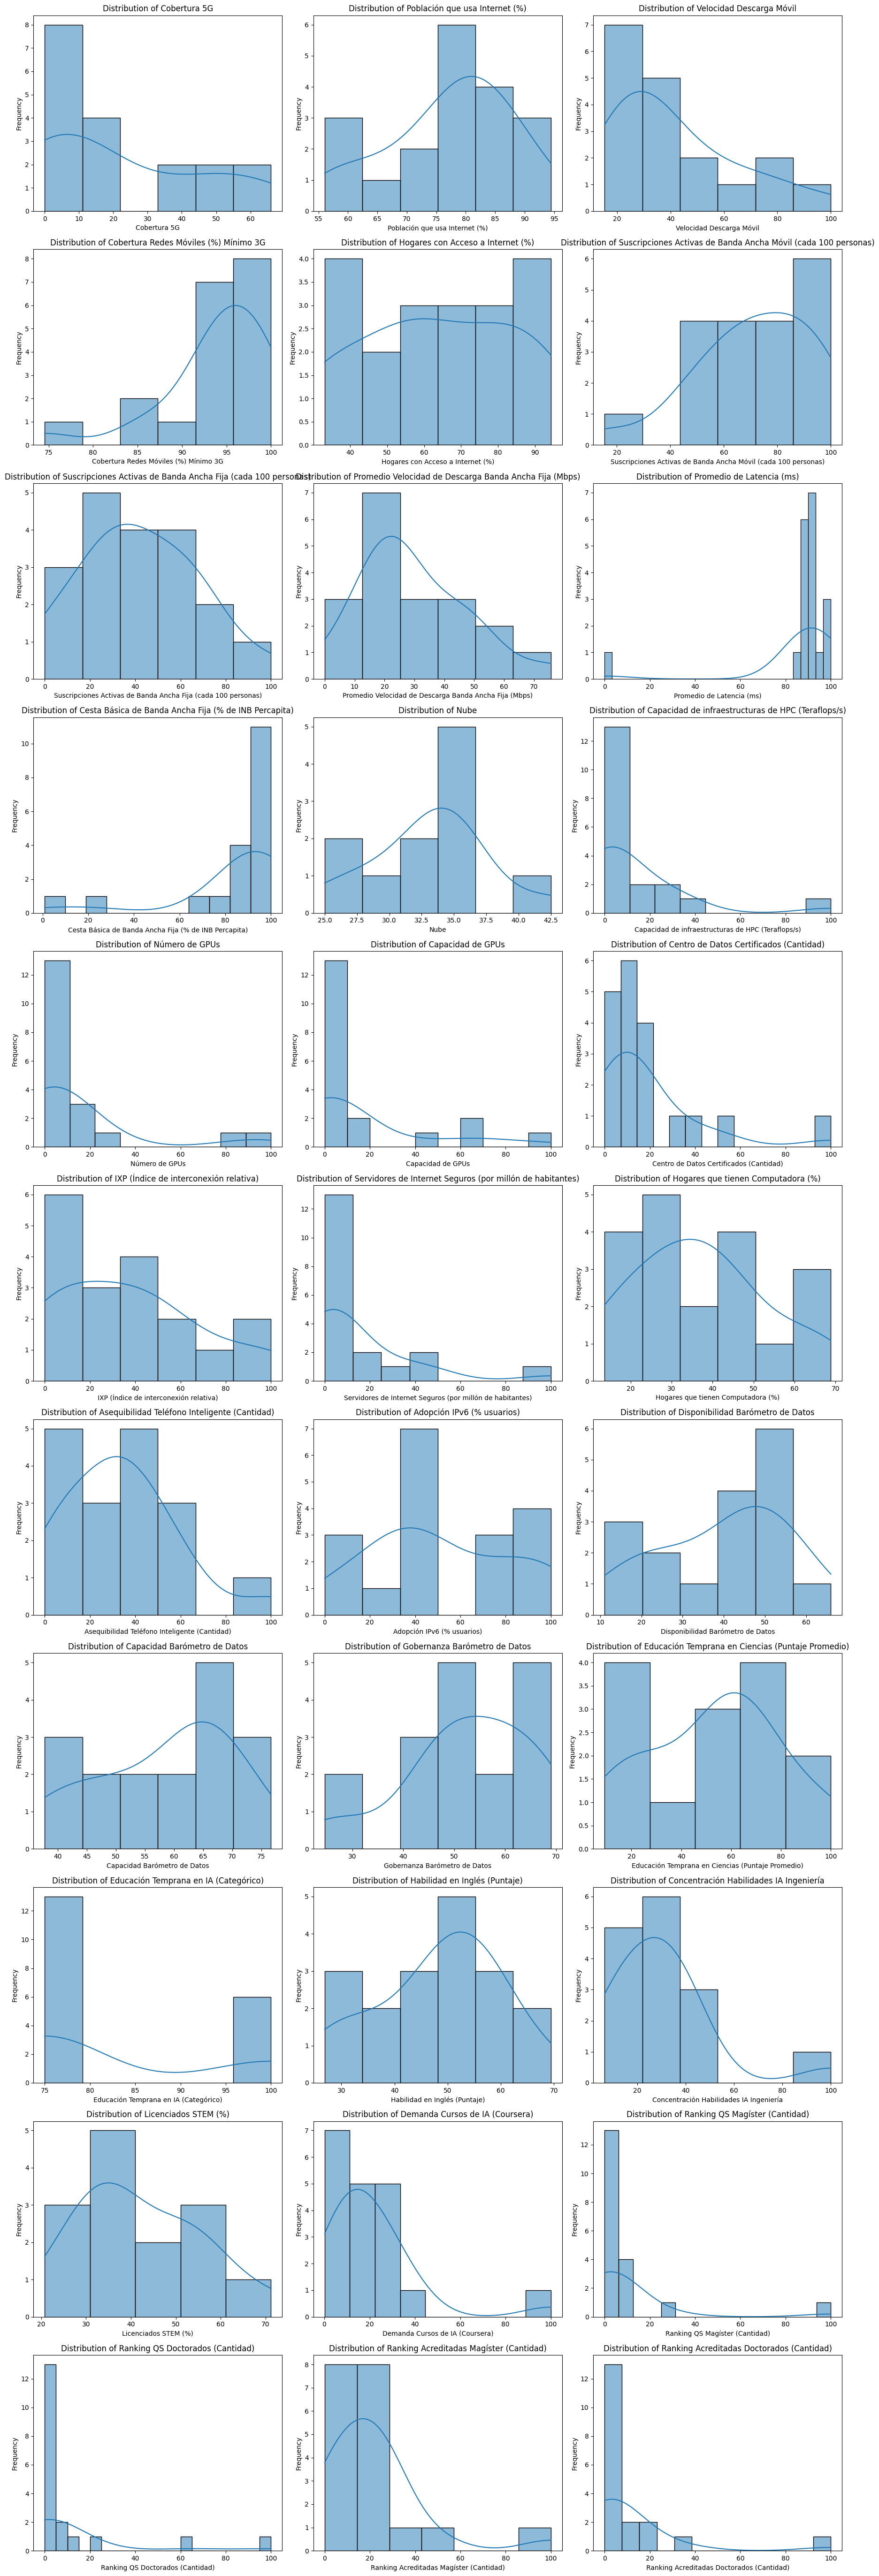

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Identify numerical columns for plotting
# Exclude the index if it's not a numerical column to be plotted
numerical_cols = fh_data.select_dtypes(include=np.number).columns

# Set up the figure size dynamically based on the number of columns
num_cols = len(numerical_cols)
num_rows = (num_cols + 2) // 3 # Roughly 3 plots per row

plt.figure(figsize=(18, 5 * num_rows))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, 3, i + 1)
    sns.histplot(fh_data[col].dropna(), kde=True) # dropna to handle missing values gracefully in plot
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

/tmp/ipython-input-3429175612.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Column')


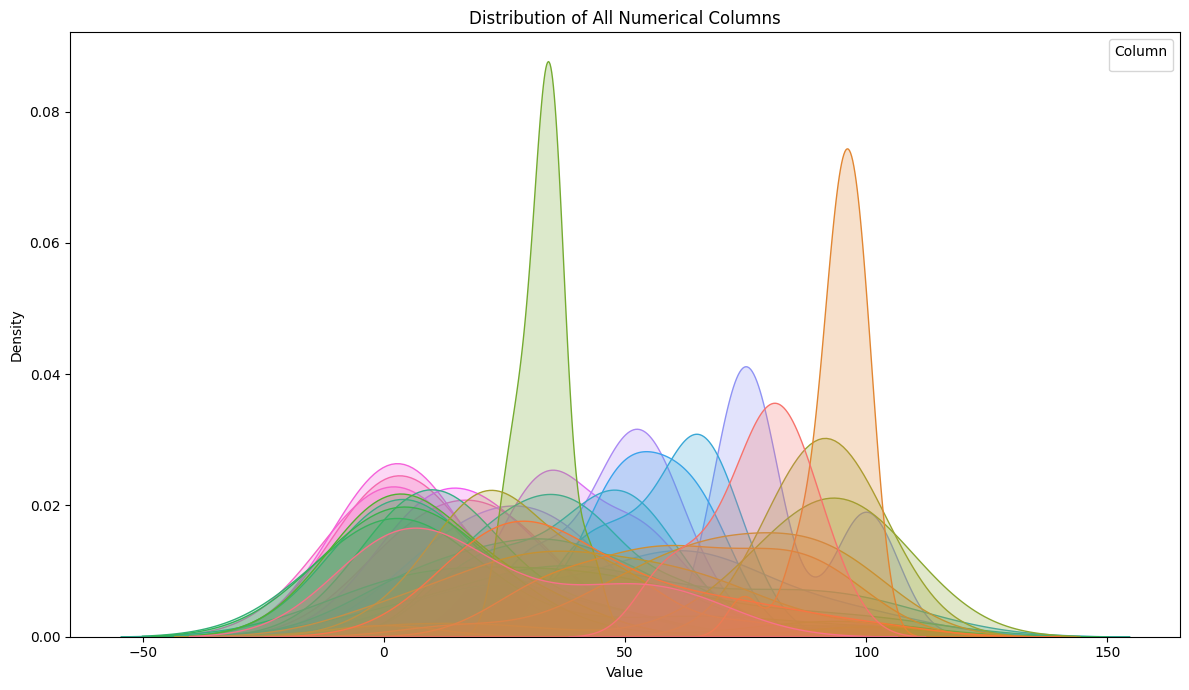

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Select only numerical columns
numerical_data = fh_data.select_dtypes(include=np.number)

# Melt the DataFrame to long format for easier plotting with seaborn
data_melted = numerical_data.melt(var_name='Column', value_name='Value')

plt.figure(figsize=(12, 7))
sns.kdeplot(data=data_melted, x='Value', hue='Column', fill=True, common_norm=False)
plt.title('Distribution of All Numerical Columns')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend(title='Column')
plt.tight_layout()
plt.show()

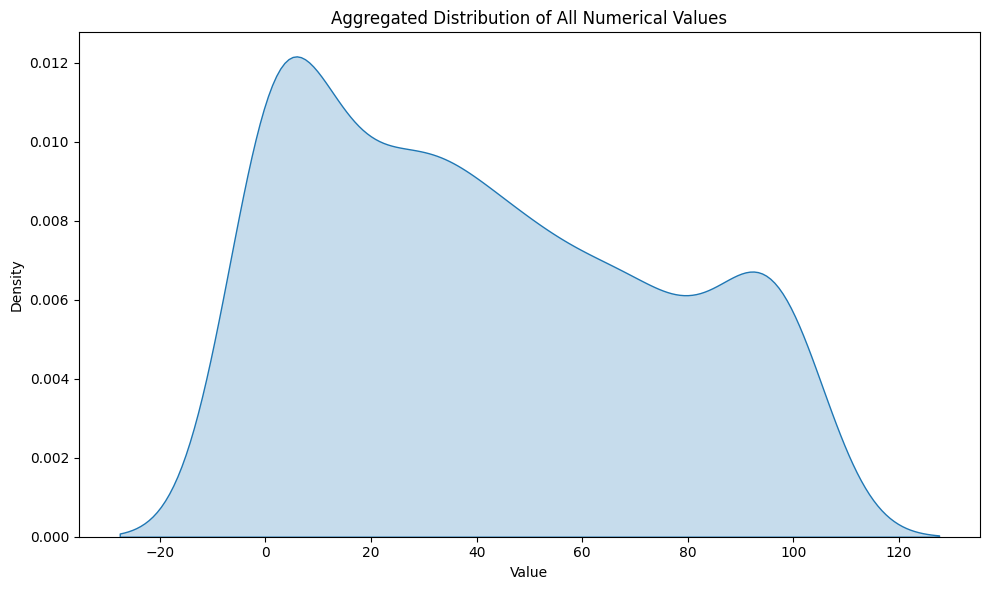

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Select only numerical columns
numerical_data = fh_data.select_dtypes(include=np.number)

# Melt the DataFrame to long format for easier plotting with seaborn
data_melted = numerical_data.melt(var_name='Column', value_name='Value')

plt.figure(figsize=(10, 6))
sns.kdeplot(data=data_melted, x='Value', fill=True, common_norm=False)
plt.title('Aggregated Distribution of All Numerical Values')
plt.xlabel('Value')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

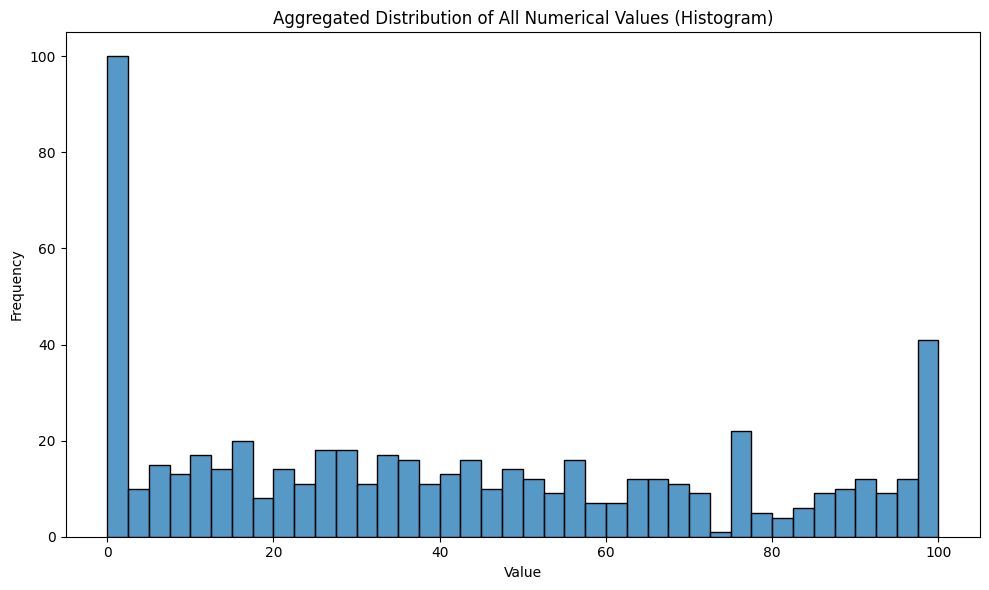

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Select only numerical columns
numerical_data = fh_data.select_dtypes(include=np.number)

# Melt the DataFrame to long format for easier plotting with seaborn
data_melted = numerical_data.melt(var_name='Column', value_name='Value')

plt.figure(figsize=(10, 6))
sns.histplot(data=data_melted, x='Value', fill=True, kde=False, bins=40) # Use histplot instead of kdeplot
plt.title('Aggregated Distribution of All Numerical Values (Histogram)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# I+D+A

In [ ]:
!gdown 1QCqCf05rw3GfQeH5UzzLZz_HcJMzwYRZ

Downloading...
From: https://drive.google.com/uc?id=1QCqCf05rw3GfQeH5UzzLZz_HcJMzwYRZ
To: /content/ida_minmax_normalized_missing_vals.xlsx
100% 17.1k/17.1k [00:00<00:00, 41.1MB/s]


In [ ]:
ida = pd.read_excel("/content/ida_minmax_normalized_missing_vals.xlsx", index_col="country").drop(columns=["total_pop", "pib_percapita"])
ida

,Publicaciones en IA (por millón de habitantes),Investigadores activos en IA (por millón de habitantes),Productividad Investigadores en IA,Impacto Investigación en IA,Presencia de Centros de Investigación de IA,Proporción de Autoras en IA,Investigación Consistente en IA,Participación en Main Tracks,Participación en Side Tracks y Events,Productividad Open Source,...,Proporción del Valor Añadido de Fabricación de Tecnología Mediana y Alta en el Valor Añadido Total (en porcentajes),Usuarios Activos de IAGen,Tiempo de Uso IaGen,Gasto Promedio de Usuario de IAGen,Usuarios Activos IA Gen (Web),Intensidad Uso IA Gen (Web),Intensidad Uso IA Gen Avanzada (Web),Gobierno Digital,Uso de IA en Participación Ciudadana,Desarrollo de IA para Participación Ciudadana
country,,,,,,,,,,,,,,,,,,,,,
Argentina,31.400383,37.753301,49.714361,25.478567,100,87.565007,31.054952,9.088378,15.147297,39.255850,...,60.627506,77.729243,98.601695,27.538071,44.493223,44.972360,46.895476,87.884806,0.0,0
Bolivia,5.072011,5.452419,58.428744,24.817671,0,65.313979,0.951918,0.000000,0.000000,80.973763,...,24.109460,NaN,NaN,NaN,31.892502,34.716587,46.051633,66.059804,38.0,23
Brasil,61.631042,80.449000,45.214360,20.420204,100,75.553903,85.085013,16.906404,22.215179,10.732268,...,68.483133,76.243436,84.076271,62.520110,51.181084,53.398339,62.297753,100.000000,53.0,100
Chile,100.000000,100.000000,59.682123,22.852858,100,57.069630,100.000000,100.000000,100.000000,17.176656,...,36.022647,97.670957,72.012712,73.828721,71.472005,72.798797,78.124153,95.023723,55.0,59
Colombia,49.522677,53.528684,54.537234,15.583097,100,72.780577,45.258867,4.943868,20.434655,40.660800,...,53.408823,73.003930,71.525424,24.364123,73.030678,73.483720,75.302100,82.985766,69.0,100
Costa Rica,41.397753,41.195455,59.753397,10.628780,50,65.700832,22.068095,0.000000,13.510534,6.765754,...,85.232366,79.546846,78.877119,76.821773,77.449522,78.195210,81.188190,79.631469,38.0,53
Cuba,29.455993,29.325685,59.875988,31.076526,25,100.000000,26.617995,0.000000,6.259419,43.922164,...,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,25.355842,0.0,0
Ecuador,74.158574,85.645737,51.359341,10.627591,0,83.242715,60.610579,0.000000,1.918188,44.092907,...,26.492097,80.876404,84.661017,30.623493,69.857383,70.706954,74.116886,97.660819,32.0,18
El Salvador,6.037839,4.915815,76.229995,5.213227,0,51.463224,1.847247,0.000000,0.000000,11.437432,...,NaN,25.348862,72.161017,60.540541,38.567290,43.224236,61.915859,56.162419,0.0,0


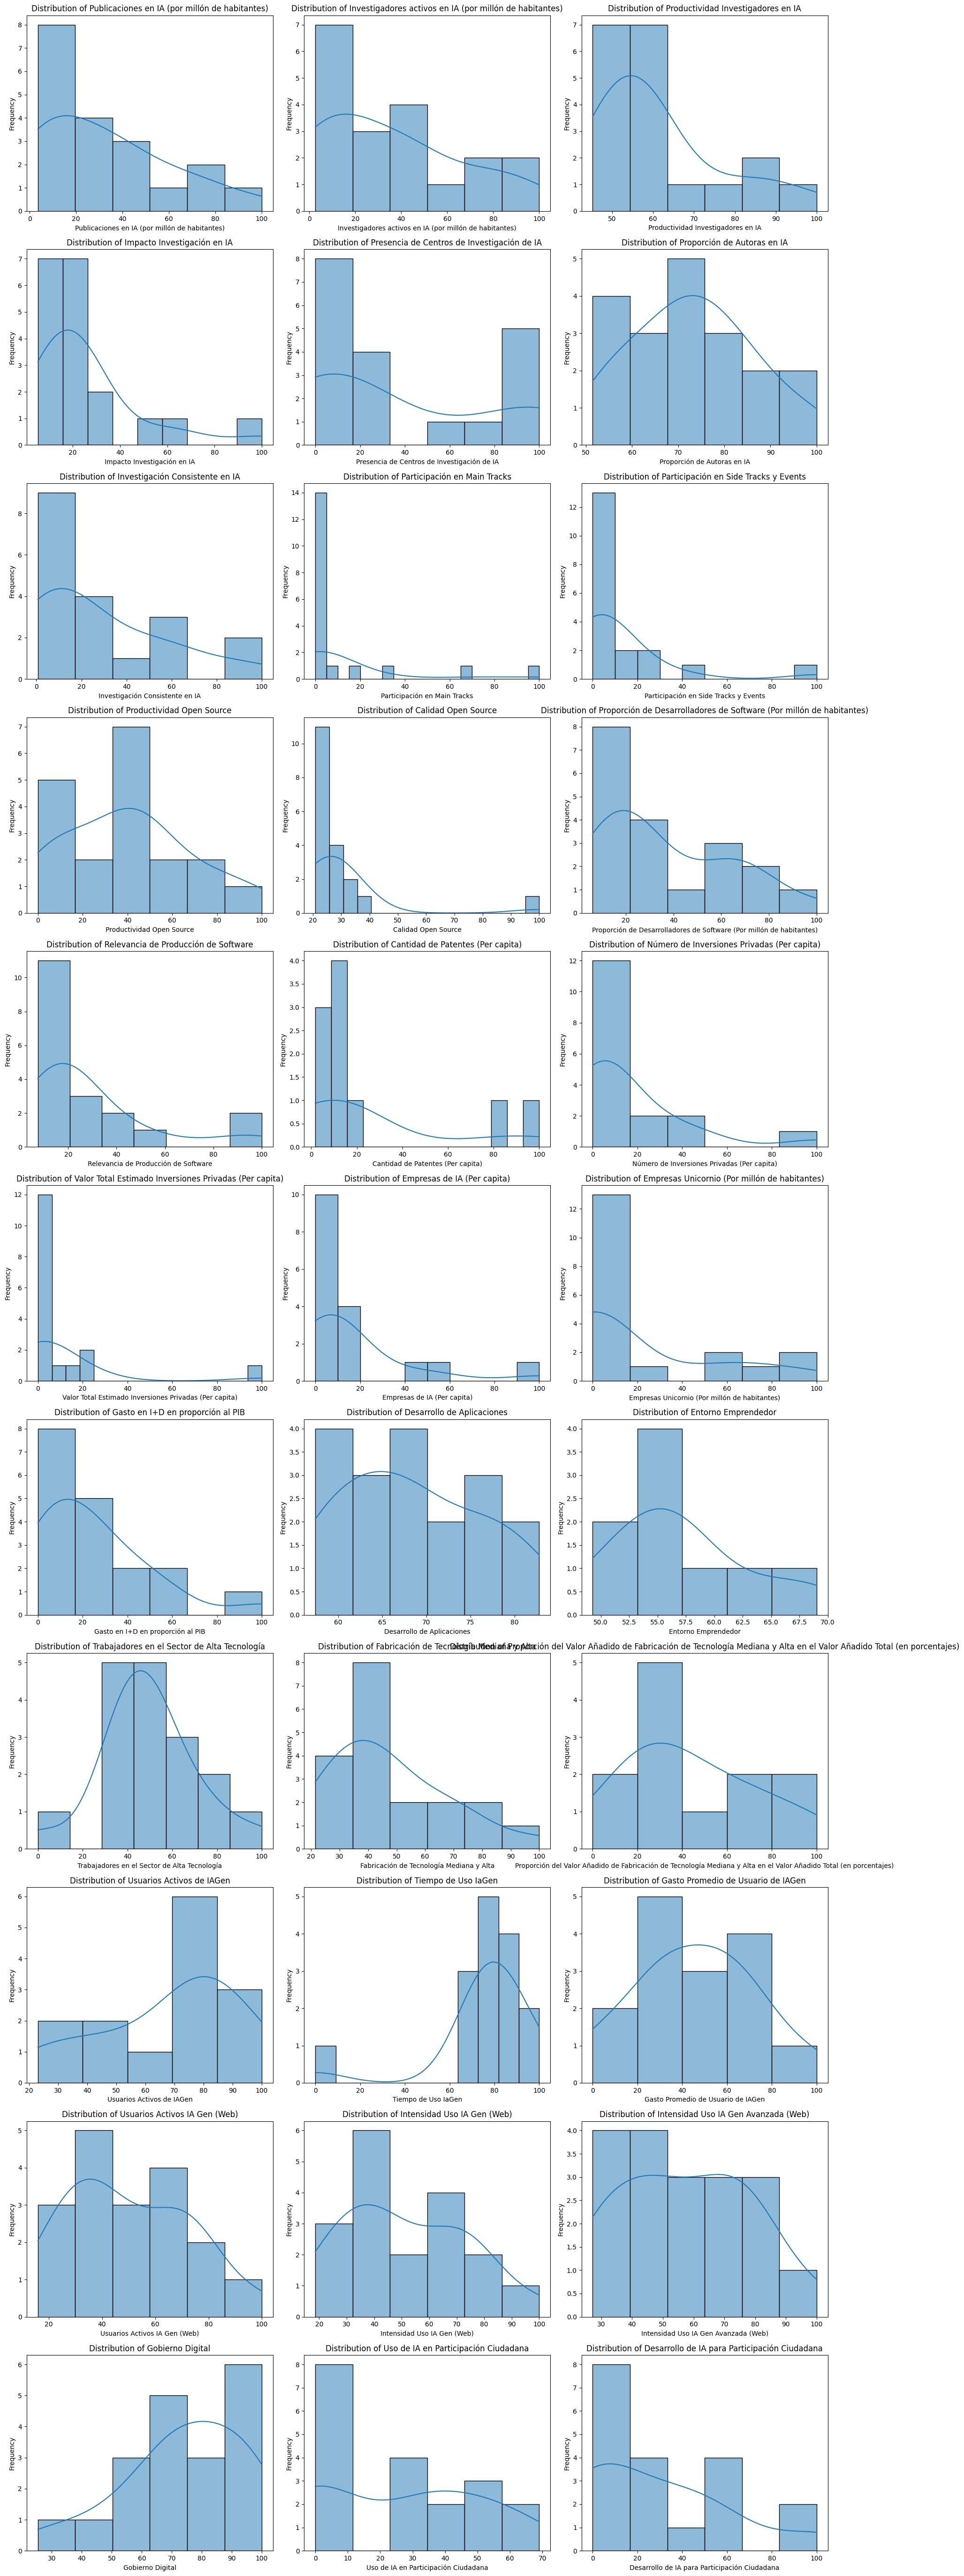

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Identify numerical columns for plotting
# Exclude the index if it's not a numerical column to be plotted
numerical_cols = ida.select_dtypes(include=np.number).columns

# Set up the figure size dynamically based on the number of columns
num_cols = len(numerical_cols)
num_rows = (num_cols + 2) // 3 # Roughly 3 plots per row

plt.figure(figsize=(18, 5 * num_rows))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, 3, i + 1)
    sns.histplot(ida[col].dropna(), kde=True) # dropna to handle missing values gracefully in plot
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

/tmp/ipython-input-2162388836.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Column')


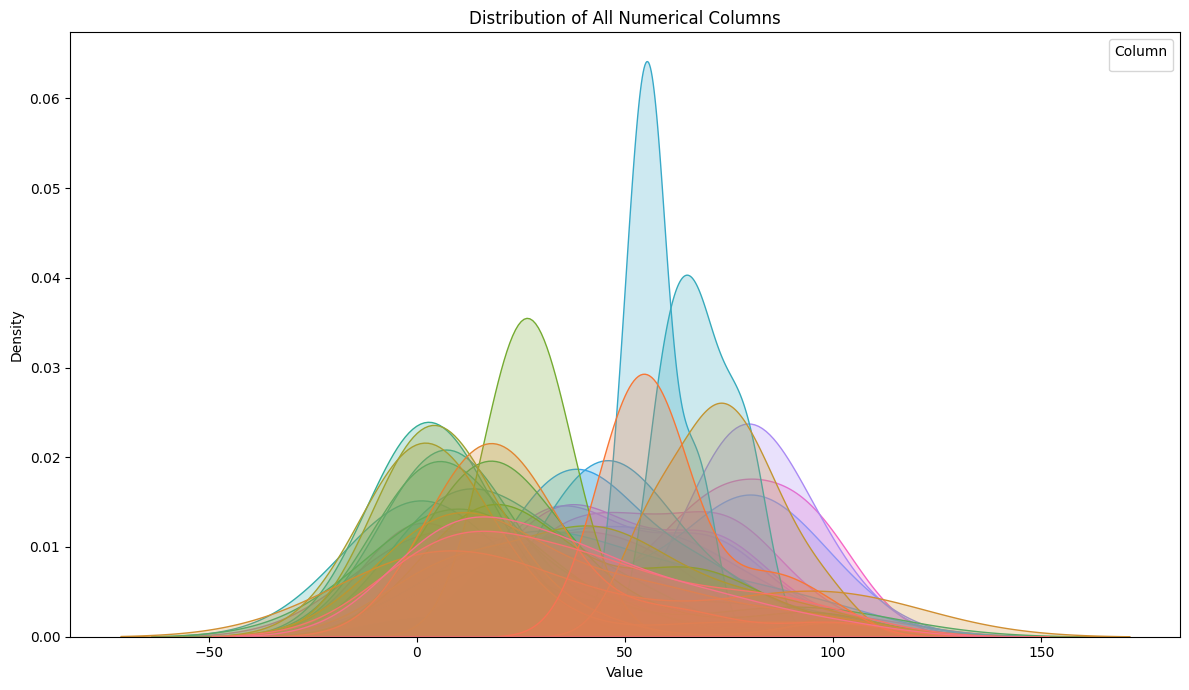

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Select only numerical columns
numerical_data = ida.select_dtypes(include=np.number)

# Melt the DataFrame to long format for easier plotting with seaborn
data_melted = numerical_data.melt(var_name='Column', value_name='Value')

plt.figure(figsize=(12, 7))
sns.kdeplot(data=data_melted, x='Value', hue='Column', fill=True, common_norm=False)
plt.title('Distribution of All Numerical Columns')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend(title='Column')
plt.tight_layout()
plt.show()

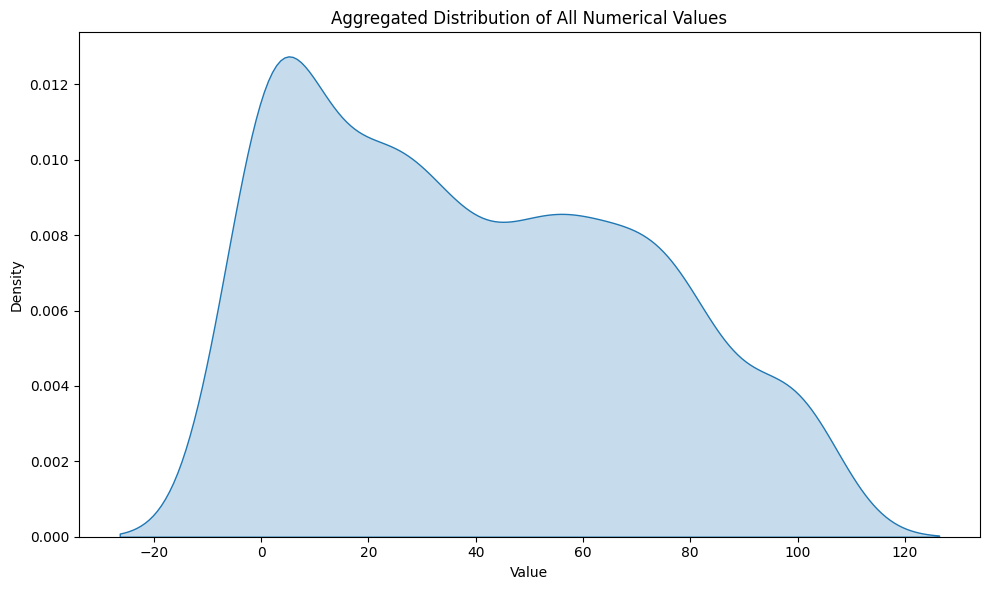

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Select only numerical columns
numerical_data = ida.select_dtypes(include=np.number)

# Melt the DataFrame to long format for easier plotting with seaborn
data_melted = numerical_data.melt(var_name='Column', value_name='Value')

plt.figure(figsize=(10, 6))
sns.kdeplot(data=data_melted, x='Value', fill=True, common_norm=False)
plt.title('Aggregated Distribution of All Numerical Values')
plt.xlabel('Value')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

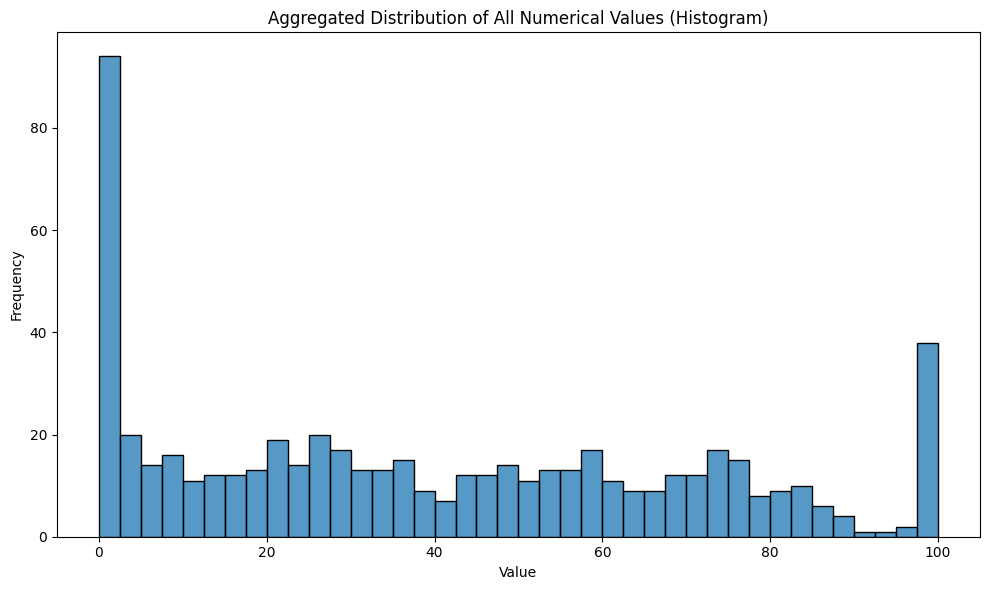

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Select only numerical columns
numerical_data = ida.select_dtypes(include=np.number)

# Melt the DataFrame to long format for easier plotting with seaborn
data_melted = numerical_data.melt(var_name='Column', value_name='Value')

plt.figure(figsize=(10, 6))
sns.histplot(data=data_melted, x='Value', fill=True, kde=False, bins=40) # Use histplot instead of kdeplot
plt.title('Aggregated Distribution of All Numerical Values (Histogram)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
ida.describe()

,Publicaciones en IA (por millón de habitantes),Investigadores activos en IA (por millón de habitantes),Productividad Investigadores en IA,Impacto Investigación en IA,Presencia de Centros de Investigación de IA,Proporción de Autoras en IA,Investigación Consistente en IA,Participación en Main Tracks,Participación en Side Tracks y Events,Productividad Open Source,...,Proporción del Valor Añadido de Fabricación de Tecnología Mediana y Alta en el Valor Añadido Total (en porcentajes),Usuarios Activos de IAGen,Tiempo de Uso IaGen,Gasto Promedio de Usuario de IAGen,Usuarios Activos IA Gen (Web),Intensidad Uso IA Gen (Web),Intensidad Uso IA Gen Avanzada (Web),Gobierno Digital,Uso de IA en Participación Ciudadana,Desarrollo de IA para Participación Ciudadana
count,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,...,12.000000,14.000000,15.000000,15.000000,18.000000,18.000000,18.000000,19.000000,19.000000,19.000000
mean,32.902317,35.850517,61.542734,26.800697,38.157895,73.219847,29.194846,12.267762,12.247243,40.318673,...,43.939215,67.828074,75.867797,45.937414,50.179744,51.626530,57.433509,74.014065,26.052632,29.157895
std,28.336971,31.178737,15.478158,23.654381,42.791826,13.303742,30.198334,27.199298,23.865459,28.495852,...,30.040740,24.674203,22.711334,27.534124,23.255421,22.755713,21.394182,20.567415,24.925386,32.944841
min,3.570341,2.633011,45.214360,5.213227,0.000000,51.463224,0.685739,0.000000,0.000000,0.000000,...,0.000000,23.004201,0.000000,0.000000,15.913904,18.604707,27.187967,25.355842,0.000000,0.000000
25%,7.553784,5.792635,50.600785,12.535192,0.000000,65.507406,2.683721,0.000000,0.000000,14.307044,...,24.675631,49.874934,72.690678,29.080782,32.181261,34.703725,41.050324,64.349553,0.000000,0.000000
50%,29.455993,29.325685,58.382732,20.223071,25.000000,72.780577,21.637953,0.000000,1.918188,40.660800,...,35.715971,76.986340,78.877119,47.408786,46.394267,47.022267,57.053067,74.059362,32.000000,23.000000
75%,46.490534,51.103992,64.148006,28.277546,87.500000,82.485349,49.543113,7.016123,14.328915,55.187546,...,62.591413,81.724698,84.368644,61.530325,70.543729,72.103254,75.005797,90.157784,45.500000,51.500000
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,69.000000,100.000000


# aux vars

In [ ]:
!gdown 1bEjW9ewzGEC9xEj6q0mtpVsk4cJHMg4sAdRvXmPrdCM

Downloading...
From (original): https://drive.google.com/uc?id=1bEjW9ewzGEC9xEj6q0mtpVsk4cJHMg4sAdRvXmPrdCM
From (redirected): https://docs.google.com/spreadsheets/d/1bEjW9ewzGEC9xEj6q0mtpVsk4cJHMg4sAdRvXmPrdCM/export?format=xlsx
To: /content/variables_aux_imputacion_ilia2026.xlsx
8.37kB [00:00, 26.1MB/s]


In [ ]:
aux_vars = pd.read_excel("/content/variables_aux_imputacion_ilia2026.xlsx", index_col="country")
aux_vars

,poblacion_2024,poblacion_urbana_porcentaje_2024,pib_per_capita_dolar_actual_2024,pib_crecimiento_anual_2024,ict_2023,hdi_2023
country,,,,,,
Argentina,45696159,92.274232,13969.783660,-1.342931,81.5,0.865
Bolivia,12413315,71.236145,4421.166099,-1.123356,68.0,0.733
Brasil,211998573,87.895855,10310.548878,3.419315,81.9,0.786
Chile,19764771,88.995091,16709.889397,2.644312,90.7,0.878
Colombia,52886363,78.521081,7919.208868,1.598332,71.9,0.788
Costa Rica,5129910,79.310767,18587.153220,4.321224,83.9,0.833
Cuba,10979783,77.166493,9605.279146,-1.061733,55.3,0.762
Ecuador,18135478,63.237693,6874.705740,-2.001255,68.2,0.777
El Salvador,6338193,75.067491,5579.659692,2.602020,61.9,0.678


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Columns to normalize
columns_to_normalize = [
    "poblacion_2024",
    "pib_per_capita_dolar_actual_2024",
    "pib_crecimiento_anual_2024",
]

# Create a copy to avoid modifying the original DataFrame directly if not intended
aux_vars_normalized = aux_vars.copy()

# Initialize MinMaxScaler with feature_range=(0, 1) to ensure min value is 0
scaler = MinMaxScaler(feature_range=(0, 100))

# Apply scaler to the selected columns
aux_vars_normalized[columns_to_normalize] = scaler.fit_transform(aux_vars[columns_to_normalize])

aux_vars_normalized["hdi_2023"] =  aux_vars_normalized["hdi_2023"]*100

print("Normalized aux_vars_normalized:")
aux_vars_normalized

Normalized aux_vars_normalized:


,poblacion_2024,poblacion_urbana_porcentaje_2024,pib_per_capita_dolar_actual_2024,pib_crecimiento_anual_2024,ict_2023,hdi_2023
country,,,,,,
Argentina,20.490107,92.274232,51.480998,9.016588,81.5,86.5
Bolivia,4.577437,71.236145,4.857068,12.023944,68.0,73.3
Brasil,100.000000,87.895855,33.613709,74.241622,81.9,78.6
Chile,8.092200,88.995091,64.860369,63.626958,90.7,87.8
Colombia,23.927774,78.521081,21.937289,49.300927,71.9,78.8
Costa Rica,1.095210,79.310767,74.026662,86.594418,83.9,83.3
Cuba,3.892059,77.166493,30.170023,12.867953,55.3,76.2
Ecuador,7.313228,63.237693,16.837196,0.000000,68.2,77.7
El Salvador,1.672895,75.067491,10.513753,63.047724,61.9,67.8


# FH imputation

## add spi

In [ ]:
!gdown 1EGZ-qc6vsrjT1J3-rT100WqVsUpXWNBw

Downloading...
From: https://drive.google.com/uc?id=1EGZ-qc6vsrjT1J3-rT100WqVsUpXWNBw
To: /content/subindicadores_spi.xlsx
100% 12.3k/12.3k [00:00<00:00, 23.0MB/s]


In [ ]:
spi = pd.read_excel("subindicadores_spi.xlsx", index_col="country")
spi = spi[["Data Use", "Data Services", "Data Products", "Data Sources", "Data Infraestructura"]]
spi

,Data Use,Data Services,Data Products,Data Sources,Data Infraestructura
country,,,,,
Argentina,90.0,85.666667,83.36250,72.925000,70.0
Bolivia,80.0,67.900000,78.06875,60.191667,65.0
Brasil,83.4,88.966667,74.90000,84.275000,80.0
Chile,100.0,88.233333,82.38750,81.275000,95.0
Colombia,80.0,88.366667,86.32500,82.500000,80.0
Costa Rica,100.0,88.966667,89.78125,81.175000,95.0
Cuba,40.0,13.000000,61.96875,31.000000,NaN
Ecuador,100.0,89.000000,80.27500,60.016667,70.0
El Salvador,90.0,77.233333,85.02500,56.441667,60.0


In [ ]:
merged_fh_test = pd.merge(fh_data, spi, left_index=True, right_index=True)
merged_fh_test = pd.merge(merged_fh_test, aux_vars_normalized, left_index=True, right_index=True)
merged_fh_test

,Cobertura 5G,Población que usa Internet (%),Velocidad Descarga Móvil,Cobertura Redes Móviles (%) Mínimo 3G,Hogares con Acceso a Internet (%),Suscripciones Activas de Banda Ancha Móvil (cada 100 personas),Suscripciones Activas de Banda Ancha Fija (cada 100 personas),Promedio Velocidad de Descarga Banda Ancha Fija (Mbps),Promedio de Latencia (ms),Cesta Básica de Banda Ancha Fija (% de INB Percapita),...,Data Services,Data Products,Data Sources,Data Infraestructura,poblacion_2024,poblacion_urbana_porcentaje_2024,pib_per_capita_dolar_actual_2024,pib_crecimiento_anual_2024,ict_2023,hdi_2023
country,,,,,,,,,,,,,,,,,,,,,
Argentina,4.77,89.2290,40.83,98.50,93.3800,72.222343,76.063145,24.680373,87.5,70.437842,...,85.666667,83.36250,72.925000,70.0,20.490107,92.274232,51.480998,9.016588,81.5,86.5
Bolivia,0.00,70.2368,16.75,91.48,56.7948,83.325350,27.270707,12.119802,89.5,84.320487,...,67.900000,78.06875,60.191667,65.0,4.577437,71.236145,4.857068,12.023944,68.0,73.3
Brasil,63.00,84.1506,100.00,93.39,84.1061,88.432403,66.077762,50.600925,92.0,98.227747,...,88.966667,74.90000,84.275000,80.0,100.000000,87.895855,33.613709,74.241622,81.9,78.6
Chile,40.07,94.4574,60.77,98.00,94.3466,99.322301,68.035493,75.642675,91.0,99.310791,...,88.233333,82.38750,81.275000,95.0,8.092200,88.995091,64.860369,63.626958,90.7,87.8
Colombia,15.30,77.3369,25.56,100.00,63.9357,77.944677,47.790875,44.613574,87.0,96.824714,...,88.366667,86.32500,82.500000,80.0,23.927774,78.521081,21.937289,49.300927,71.9,78.8
Costa Rica,9.76,85.3951,30.33,95.00,81.7396,92.107125,66.430778,31.746379,92.5,96.406266,...,88.966667,89.78125,81.175000,95.0,1.095210,79.310767,74.026662,86.594418,83.9,83.3
Cuba,NaN,71.2750,NaN,74.57,33.3821,44.065284,0.000000,0.000000,0.0,24.014669,...,13.000000,61.96875,31.000000,NaN,3.892059,77.166493,30.170023,12.867953,55.3,76.2
Ecuador,21.99,77.1727,31.70,96.27,65.9755,57.269610,44.498203,29.350891,89.5,91.040278,...,89.000000,80.27500,60.016667,70.0,7.313228,63.237693,16.837196,0.000000,68.2,77.7
El Salvador,0.00,67.6558,22.59,92.00,34.2224,66.119881,29.410214,21.192543,91.5,86.265042,...,77.233333,85.02500,56.441667,60.0,1.672895,75.067491,10.513753,63.047724,61.9,67.8


In [ ]:
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
import pandas as pd
import numpy as np

# Define a list of random seeds to test
random_seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

# Get the columns from merged_fh_test (assuming they are the same as used previously)
columns = list(merged_fh_test.columns)

# Find the positions of NaN values in the original merged_fh_test
original_nans = merged_fh_test.isnull()

# Dictionary to store imputed values for original NaNs for each seed
imputed_values_comparison = {}

print("Running IterativeImputer with different random seeds to observe imputation variability:\n")

for seed in random_seeds:
    print(f"Processing with random_state = {seed}...")

    imputer = IterativeImputer(
        max_iter=100,
        sample_posterior=True,
        random_state=seed,
        min_value=0,
        max_value=100
    )

    # Fit-transform the data
    imputed_data_array = imputer.fit_transform(merged_fh_test[columns])
    imputed_df_current = pd.DataFrame(imputed_data_array, columns=columns, index=merged_fh_test.index)

    # Extract only the imputed values at the positions where merged_fh_test originally had NaNs
    # We use .loc to ensure we get values based on the original NaN locations
    imputed_nans_for_seed = imputed_df_current[original_nans].stack()

    # Store these values in our comparison dictionary
    imputed_values_comparison[f'Imputed_Seed_{seed}'] = imputed_nans_for_seed

    print(f"\tNumber of imputed values for original NaNs: {len(imputed_nans_for_seed)}")

# Combine all imputed values for original NaNs into a single DataFrame for easy comparison
comparison_df = pd.DataFrame(imputed_values_comparison)

#comparison_df["avg_before_imputing"] = merged_fh_test[columns].mean(axis=1)
comparison_df["std_of_all_seeds"] = comparison_df.std(axis=1)
comparison_df["avg_of_all_seeds"] = comparison_df.mean(axis=1)

comparison_df = comparison_df.sort_values(by="std_of_all_seeds", ascending=False)

print("\nComparison of imputed values for originally missing data across different seeds:")
display(comparison_df[["std_of_all_seeds", "avg_of_all_seeds"]])

print("\nNote: If all values for a specific (country, column) pair are NaN across seeds, it means that original value was not NaN. This table only shows values for cells that were originally NaN in merged_fh_test.")

Running IterativeImputer with different random seeds to observe imputation variability:

Processing with random_state = 0...
	Number of imputed values for original NaNs: 36
Processing with random_state = 1...
	Number of imputed values for original NaNs: 36
Processing with random_state = 2...
	Number of imputed values for original NaNs: 36
Processing with random_state = 3...
	Number of imputed values for original NaNs: 36
Processing with random_state = 4...
	Number of imputed values for original NaNs: 36
Processing with random_state = 5...
	Number of imputed values for original NaNs: 36
Processing with random_state = 6...
	Number of imputed values for original NaNs: 36
Processing with random_state = 7...
	Number of imputed values for original NaNs: 36
Processing with random_state = 8...
	Number of imputed values for original NaNs: 36
Processing with random_state = 9...
	Number of imputed values for original NaNs: 36

Comparison of imputed values for originally missing data across differ

std_of_all_seeds  \
country                                                                                    
Uruguay              IXP (Índice de interconexión relativa)                    22.715327   
Venezuela            Disponibilidad Barómetro de Datos                         14.003064   
Cuba                 Velocidad Descarga Móvil                                  13.566251   
                     Disponibilidad Barómetro de Datos                         13.288131   
Honduras             Concentración Habilidades IA Ingeniería                   12.463504   
Jamaica              Adopción IPv6 (% usuarios)                                10.076095   
Bolivia              Licenciados STEM (%)                                       9.867985   
El Salvador          Concentración Habilidades IA Ingeniería                    8.650092   
Paraguay             Concentración Habilidades IA Ingeniería                    8.382118   
Jamaica              Habilidad en Inglés (Puntaje)                              7.969546   
                     Licenciados STEM (%)                                       7.540246   
Guatemala            Licenciados STEM (%)                                       7.391597   
Venezuela            Gobernanza Barómetro de Datos                              7.379316   
Paraguay             Licenciados STEM (%)                                       7.233021   
Venezuela            Asequibilidad Teléfono Inteligente (Cantidad)              6.098220   
                     Educación Temprana en Ciencias (Puntaje Promedio)          5.712915   
Cuba                 Data Infraestructura                                       5.218690   
                     Educación Temprana en Ciencias (Puntaje Promedio)          5.056808   
                     Gobernanza Barómetro de Datos                              5.002263   
Venezuela            Capacidad Barómetro de Datos                               4.955445   
Cuba                 Capacidad Barómetro de Datos                               4.563603   
Venezuela            Licenciados STEM (%)                                       4.234870   
Cuba                 Asequibilidad Teléfono Inteligente (Cantidad)              3.333177   
Honduras             Educación Temprana en Ciencias (Puntaje Promedio)          3.171679   
Ecuador              Educación Temprana en Ciencias (Puntaje Promedio)          2.983546   
Bolivia              Educación Temprana en Ciencias (Puntaje Promedio)          2.784682   
Cuba                 Concentración Habilidades IA Ingeniería                    2.569465   
Costa Rica           Nube                                                       1.642651   
Cuba                 Nube                                                       1.345257   
El Salvador          Nube                                                       0.936446   
Honduras             Nube                                                       0.728707   
República Dominicana Nube                                                       0.641899   
Jamaica              Nube                                                       0.550920   
Panamá               Nube                                                       0.546188   
Guatemala            Nube                                                       0.347447   
Cuba                 Cobertura 5G                                               0.000000   

                                                                        avg_of_all_seeds  
country                                                                                   
Uruguay              IXP (Índice de interconexión relativa)                    40.144418  
Venezuela            Disponibilidad Barómetro de Datos                         31.452608  
Cuba                 Velocidad Descarga Móvil                                  17.698259  
                     Disponibilidad Barómetro de Datos                         29.718626  
Honduras             Concentr


Note: If all values for a specific (country, column) pair are NaN across seeds, it means that original value was not NaN. This table only shows values for cells that were originally NaN in merged_fh_test.


## actual values fh 2025

In [ ]:
!gdown 1tcdnEKsncH-s6IBtHSe7Cjts0h-oQMUF

Downloading...
From: https://drive.google.com/uc?id=1tcdnEKsncH-s6IBtHSe7Cjts0h-oQMUF
To: /content/Datos ILIA 2025.xlsx
100% 87.9k/87.9k [00:00<00:00, 78.7MB/s]


In [ ]:
ilia_scores_2025 = pd.read_excel("/content/Datos ILIA 2025.xlsx", sheet_name="Puntaje ILIA (PROSA)")
ilia_scores_2025 = ilia_scores_2025[ilia_scores_2025["Dimensión"] == "Factores Habilitantes"]
ilia_scores_2025 = ilia_scores_2025.dropna().reset_index(drop=True)
ilia_scores_2025 = ilia_scores_2025.drop(columns=["Dimensión", "Subdimensión", "Indicador"])
ilia_scores_2025 = ilia_scores_2025.set_index("Subindicador").T
ilia_scores_2025.index.names = ["country"]
ilia_scores_2025.columns.names = [None]
ilia_scores_2025.columns = fh_data.columns
ilia_scores_2025

,Cobertura 5G,Población que usa Internet (%),Velocidad Descarga Móvil,Cobertura Redes Móviles (%) Mínimo 3G,Hogares con Acceso a Internet (%),Suscripciones Activas de Banda Ancha Móvil (cada 100 personas),Suscripciones Activas de Banda Ancha Fija (cada 100 personas),Promedio Velocidad de Descarga Banda Ancha Fija (Mbps),Promedio de Latencia (ms),Cesta Básica de Banda Ancha Fija (% de INB Percapita),...,Educación Temprana en Ciencias (Puntaje Promedio),Educación Temprana en IA (Categórico),Habilidad en Inglés (Puntaje),Concentración Habilidades IA Ingeniería,Licenciados STEM (%),Demanda Cursos de IA (Coursera),Ranking QS Magíster (Cantidad),Ranking QS Doctorados (Cantidad),Ranking Acreditadas Magíster (Cantidad),Ranking Acreditadas Doctorados (Cantidad)
country,,,,,,,,,,,,,,,,,,,,,
Argentina,4.770000,89.2290,40.830000,98.50,93.3800,72.222343,76.063145,24.680373,87.5,70.437842,...,58.381503,75.0,69.421488,39.042357,33.960673,15.603120,11.691511,21.584898,13.020092,16.188674
Bolivia,0.000000,70.2368,16.750000,91.48,56.7948,83.325350,27.270707,12.119802,89.5,84.320487,...,38.681451,75.0,54.132231,6.445672,24.327766,8.931438,0.000000,0.000000,27.670998,0.000000
Brasil,63.000000,84.1506,100.000000,93.39,84.1061,88.432403,66.077762,50.600925,92.0,98.227747,...,57.225434,100.0,29.752066,25.414365,37.621719,11.170665,2.292365,7.758978,2.406983,9.310773
Chile,40.070000,94.4574,60.770000,98.00,94.3466,99.322301,68.035493,75.642675,91.0,99.310791,...,100.000000,100.0,54.132231,43.093923,50.470402,25.768054,29.544675,100.000000,49.548882,100.000000
Colombia,15.300000,77.3369,25.560000,100.00,63.9357,77.944677,47.790875,44.613574,87.0,96.824714,...,64.161850,75.0,37.603306,37.937385,56.820754,100.000000,12.026017,6.262233,20.236086,4.696675
Costa Rica,9.760000,85.3951,30.330000,95.00,81.7396,92.107125,66.430778,31.746379,92.5,96.406266,...,65.317919,100.0,57.851240,100.000000,36.386261,40.791110,9.480153,64.175036,8.295134,0.000000
Cuba,0.016963,71.2750,19.601696,74.57,33.3821,44.065284,0.000000,0.000000,0.0,24.014669,...,36.628072,75.0,52.066116,25.879005,20.802263,0.179289,0.000000,0.000000,0.000000,0.000000
Ecuador,21.990000,77.1727,31.700000,96.27,65.9755,57.269610,44.498203,29.350891,89.5,91.040278,...,50.699107,100.0,29.338843,12.154696,46.159313,32.957231,8.075795,0.000000,23.554403,0.000000
El Salvador,0.000000,67.6558,22.590000,92.00,34.2224,66.119881,29.410214,21.192542,91.5,86.265042,...,19.075145,75.0,49.173554,30.113016,52.950268,12.289456,0.000000,0.000000,6.712129,0.000000


In [ ]:
# Initialize a new column in comparison_df for the actual values
comparison_df['Actual_ILIA_2025_Value'] = np.nan

# Iterate through the multi-index of comparison_df (which are country and column names)
for (country, col_name) in comparison_df.index:
    # Check if the country and column exist in ilia_scores_2025
    if country in ilia_scores_2025.index and col_name in ilia_scores_2025.columns:
        # Assign the actual value from ilia_scores_2025 to the comparison_df
        comparison_df.loc[(country, col_name), 'Actual_ILIA_2025_Value'] = ilia_scores_2025.loc[country, col_name]

# Display the updated comparison_df, sorted to keep the highest std_of_all_seeds at the top
comparison_df["avg of seeds and actual value difference"] = comparison_df["avg_of_all_seeds"] - comparison_df["Actual_ILIA_2025_Value"]
display(comparison_df[["std_of_all_seeds", "avg_of_all_seeds", "Actual_ILIA_2025_Value", "avg of seeds and actual value difference"]].sort_values("avg of seeds and actual value difference", ascending=False))

std_of_all_seeds  \
country                                                                                    
Cuba                 Gobernanza Barómetro de Datos                              5.002263   
                     Disponibilidad Barómetro de Datos                         13.288131   
Bolivia              Licenciados STEM (%)                                       9.867985   
Venezuela            Gobernanza Barómetro de Datos                              7.379316   
Guatemala            Licenciados STEM (%)                                       7.391597   
Ecuador              Educación Temprana en Ciencias (Puntaje Promedio)          2.983546   
El Salvador          Nube                                                       0.936446   
Paraguay             Concentración Habilidades IA Ingeniería                    8.382118   
Venezuela            Disponibilidad Barómetro de Datos                         14.003064   
Paraguay             Licenciados STEM (%)                                       7.233021   
Costa Rica           Nube                                                       1.642651   
Venezuela            Asequibilidad Teléfono Inteligente (Cantidad)              6.098220   
Bolivia              Educación Temprana en Ciencias (Puntaje Promedio)          2.784682   
Jamaica              Nube                                                       0.550920   
Cuba                 Asequibilidad Teléfono Inteligente (Cantidad)              3.333177   
Panamá               Nube                                                       0.546188   
República Dominicana Nube                                                       0.641899   
Honduras             Nube                                                       0.728707   
Cuba                 Cobertura 5G                                               0.000000   
                     Capacidad Barómetro de Datos                               4.563603   
                     Nube                                                       1.345257   
                     Velocidad Descarga Móvil                                  13.566251   
Jamaica              Licenciados STEM (%)                                       7.540246   
Guatemala            Nube                                                       0.347447   
Jamaica              Adopción IPv6 (% usuarios)                                10.076095   
Honduras             Concentración Habilidades IA Ingeniería                   12.463504   
El Salvador          Concentración Habilidades IA Ingeniería                    8.650092   
Venezuela            Capacidad Barómetro de Datos                               4.955445   
                     Licenciados STEM (%)                                       4.234870   
Uruguay              IXP (Índice de interconexión relativa)                    22.715327   
Honduras             Educación Temprana en Ciencias (Puntaje Promedio)          3.171679   
Cuba                 Educación Temprana en Ciencias (Puntaje Promedio)          5.056808   
                     Concentración Habilidades IA Ingeniería                    2.569465   
Venezuela            Educación Temprana en Ciencias (Puntaje Promedio)          5.712915   
Jamaica              Habilidad en Inglés (Puntaje)                              7.969546   
Cuba                 Data Infraestructura                                       5.218690   

                                                                        avg_of_all_seeds  \
country                                                                                    
Cuba                 Gobernanza Barómetro de Datos                             51.926704   
                     Disponibilidad Barómetro de Datos                         29.718626   
Bolivia              Licenciados STEM (%)                                      49.967321   
Venezuela            Gobernanza Barómetro de Datos                             49.344580   
Guatemala            Li

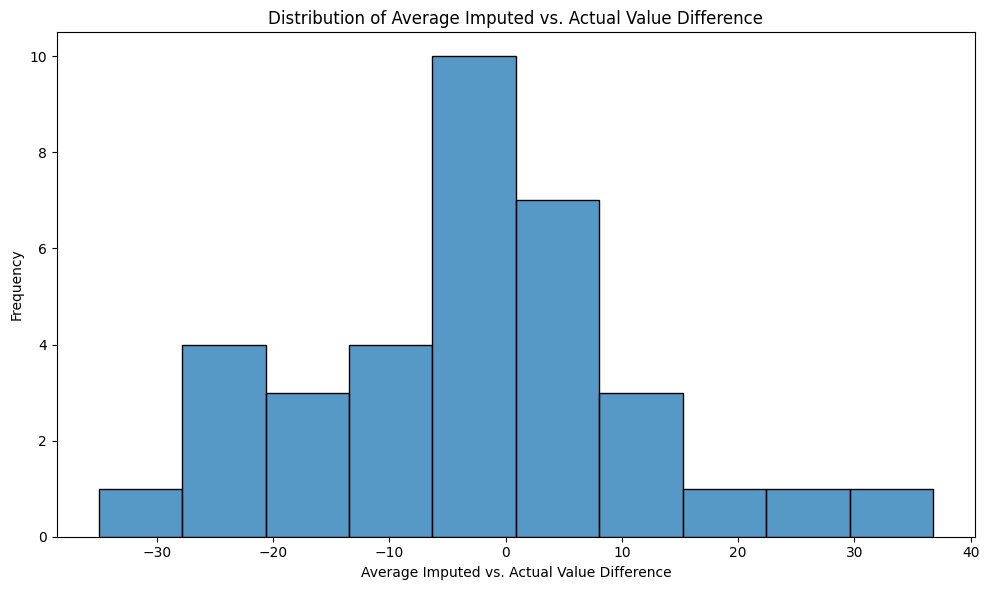

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(comparison_df["avg of seeds and actual value difference"].dropna())
plt.title('Distribution of Average Imputed vs. Actual Value Difference')
plt.xlabel('Average Imputed vs. Actual Value Difference')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# I+D+A imputation

In [ ]:
merged_ida_test = pd.merge(ida, aux_vars_normalized, left_index=True, right_index=True)
merged_ida_test

,Publicaciones en IA (por millón de habitantes),Investigadores activos en IA (por millón de habitantes),Productividad Investigadores en IA,Impacto Investigación en IA,Presencia de Centros de Investigación de IA,Proporción de Autoras en IA,Investigación Consistente en IA,Participación en Main Tracks,Participación en Side Tracks y Events,Productividad Open Source,...,Intensidad Uso IA Gen Avanzada (Web),Gobierno Digital,Uso de IA en Participación Ciudadana,Desarrollo de IA para Participación Ciudadana,poblacion_2024,poblacion_urbana_porcentaje_2024,pib_per_capita_dolar_actual_2024,pib_crecimiento_anual_2024,ict_2023,hdi_2023
country,,,,,,,,,,,,,,,,,,,,,
Argentina,31.400383,37.753301,49.714361,25.478567,100,87.565007,31.054952,9.088378,15.147297,39.255850,...,46.895476,87.884806,0.0,0,20.490107,92.274232,51.480998,9.016588,81.5,86.5
Bolivia,5.072011,5.452419,58.428744,24.817671,0,65.313979,0.951918,0.000000,0.000000,80.973763,...,46.051633,66.059804,38.0,23,4.577437,71.236145,4.857068,12.023944,68.0,73.3
Brasil,61.631042,80.449000,45.214360,20.420204,100,75.553903,85.085013,16.906404,22.215179,10.732268,...,62.297753,100.000000,53.0,100,100.000000,87.895855,33.613709,74.241622,81.9,78.6
Chile,100.000000,100.000000,59.682123,22.852858,100,57.069630,100.000000,100.000000,100.000000,17.176656,...,78.124153,95.023723,55.0,59,8.092200,88.995091,64.860369,63.626958,90.7,87.8
Colombia,49.522677,53.528684,54.537234,15.583097,100,72.780577,45.258867,4.943868,20.434655,40.660800,...,75.302100,82.985766,69.0,100,23.927774,78.521081,21.937289,49.300927,71.9,78.8
Costa Rica,41.397753,41.195455,59.753397,10.628780,50,65.700832,22.068095,0.000000,13.510534,6.765754,...,81.188190,79.631469,38.0,53,1.095210,79.310767,74.026662,86.594418,83.9,83.3
Cuba,29.455993,29.325685,59.875988,31.076526,25,100.000000,26.617995,0.000000,6.259419,43.922164,...,NaN,25.355842,0.0,0,3.892059,77.166493,30.170023,12.867953,55.3,76.2
Ecuador,74.158574,85.645737,51.359341,10.627591,0,83.242715,60.610579,0.000000,1.918188,44.092907,...,74.116886,97.660819,32.0,18,7.313228,63.237693,16.837196,0.000000,68.2,77.7
El Salvador,6.037839,4.915815,76.229995,5.213227,0,51.463224,1.847247,0.000000,0.000000,11.437432,...,61.915859,56.162419,0.0,0,1.672895,75.067491,10.513753,63.047724,61.9,67.8


In [ ]:
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
import pandas as pd
import numpy as np

# Define a list of random seeds to test
random_seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

# Get the columns from merged_ida_test (assuming they are the same as used previously)
columns = list(merged_ida_test.columns)

# Find the positions of NaN values in the original merged_ida_test
original_nans = merged_ida_test.isnull()

# Dictionary to store imputed values for original NaNs for each seed
imputed_values_comparison = {}

print("Running IterativeImputer with different random seeds to observe imputation variability:\n")

for seed in random_seeds:
    print(f"Processing with random_state = {seed}...")

    imputer = IterativeImputer(
        max_iter=30,
        sample_posterior=True,
        random_state=seed,
        min_value=0,
        max_value=100
    )

    # Fit-transform the data
    imputed_data_array = imputer.fit_transform(merged_ida_test[columns])
    imputed_df_current = pd.DataFrame(imputed_data_array, columns=columns, index=merged_ida_test.index)

    # Extract only the imputed values at the positions where merged_ida_test originally had NaNs
    # We use .loc to ensure we get values based on the original NaN locations
    imputed_nans_for_seed = imputed_df_current[original_nans].stack()

    # Store these values in our comparison dictionary
    imputed_values_comparison[f'Imputed_Seed_{seed}'] = imputed_nans_for_seed

    print(f"\tNumber of imputed values for original NaNs: {len(imputed_nans_for_seed)}")

# Combine all imputed values for original NaNs into a single DataFrame for easy comparison
comparison_df = pd.DataFrame(imputed_values_comparison)

#comparison_df["avg_before_imputing"] = merged_ida_test[columns].mean(axis=1)
comparison_df["std_of_all_seeds"] = comparison_df.std(axis=1)
comparison_df["avg_of_all_seeds"] = comparison_df.mean(axis=1)

comparison_df = comparison_df.sort_values(by="std_of_all_seeds", ascending=False)

print("\nComparison of imputed values for originally missing data across different seeds:")
display(comparison_df[["std_of_all_seeds", "avg_of_all_seeds"]])

print("\nNote: If all values for a specific (country, column) pair are NaN across seeds, it means that original value was not NaN. This table only shows values for cells that were originally NaN in merged_ida_test.")

Running IterativeImputer with different random seeds to observe imputation variability:

Processing with random_state = 0...
	Number of imputed values for original NaNs: 52
Processing with random_state = 1...
	Number of imputed values for original NaNs: 52
Processing with random_state = 2...
	Number of imputed values for original NaNs: 52
Processing with random_state = 3...
	Number of imputed values for original NaNs: 52
Processing with random_state = 4...
	Number of imputed values for original NaNs: 52
Processing with random_state = 5...
	Number of imputed values for original NaNs: 52
Processing with random_state = 6...
	Number of imputed values for original NaNs: 52
Processing with random_state = 7...
	Number of imputed values for original NaNs: 52
Processing with random_state = 8...
	Number of imputed values for original NaNs: 52
Processing with random_state = 9...
	Number of imputed values for original NaNs: 52

Comparison of imputed values for originally missing data across differ

std_of_all_seeds  \
country                                                                                     
Cuba                 Usuarios Activos de IAGen                                  32.015393   
                     Valor Total Estimado Inversiones Privadas (Per ...         23.700753   
Ecuador              Cantidad de Patentes (Per capita)                          23.037415   
Guatemala            Cantidad de Patentes (Per capita)                          22.743848   
República Dominicana Proporción del Valor Añadido de Fabricación de ...         22.647649   
                     Cantidad de Patentes (Per capita)                          22.601823   
Paraguay             Cantidad de Patentes (Per capita)                          22.323626   
Jamaica              Trabajadores en el Sector de Alta Tecnología               21.282764   
Bolivia              Cantidad de Patentes (Per capita)                          21.259196   
Cuba                 Proporción del Valor Añadido de Fabricación de ...         21.246714   
Venezuela            Proporción del Valor Añadido de Fabricación de ...         20.927503   
Bolivia              Tiempo de Uso IaGen                                        18.509218   
Paraguay             Tiempo de Uso IaGen                                        17.928435   
Jamaica              Usuarios Activos de IAGen                                  17.743983   
El Salvador          Proporción del Valor Añadido de Fabricación de ...         17.493366   
Honduras             Tiempo de Uso IaGen                                        16.591865   
Venezuela            Cantidad de Patentes (Per capita)                          16.508058   
República Dominicana Gasto en I+D en proporción al PIB                          15.809650   
Jamaica              Cantidad de Patentes (Per capita)                          15.223276   
Cuba                 Trabajadores en el Sector de Alta Tecnología               15.000238   
Honduras             Cantidad de Patentes (Per capita)                          14.653447   
Bolivia              Usuarios Activos de IAGen                                  14.590775   
Honduras             Usuarios Activos de IAGen                                  14.418468   
El Salvador          Cantidad de Patentes (Per capita)                          14.064391   
Paraguay             Usuarios Activos de IAGen                                  13.785284   
Guatemala            Proporción del Valor Añadido de Fabricación de ...         13.671004   
Honduras             Proporción del Valor Añadido de Fabricación de ...         13.641678   
Jamaica              Proporción del Valor Añadido de Fabricación de ...         13.507707   
Cuba                 Intensidad Uso IA Gen Avanzada (Web)                       13.171928   
Bolivia              Valor Total Estimado Inversiones Privadas (Per ...         12.098138   
Jamaica              Tiempo de Uso IaGen                                        10.845341   
Paraguay             Gasto Promedio de Usuario de IAGen                          9.848119   
Jamaica              Gasto Promedio de Usuario de IAGen                          8.497085   
Bolivia              Gasto Promedio de Usuario de IAGen                          7.732978   
Honduras             Gasto Promedio de Usuario de IAGen                          7.408781   
Cuba                 Usuarios Activos IA Gen (Web)                               7.370278   
                     Empresas de IA (Per capita)                                 7.014596   
                     Intensidad Uso IA Gen (Web)                                 6.143495   
                     Desarrollo de Aplicaciones                                  4.995467   
Bolivia              Número de Inversiones Privadas (Per capita)                 3.091740   
Cuba                 Número de Inversiones Privadas (Per capita)                 1.836400   
Panamá               Entorno Emprendedor                                  


Note: If all values for a specific (country, column) pair are NaN across seeds, it means that original value was not NaN. This table only shows values for cells that were originally NaN in merged_ida_test.


In [ ]:
ilia_scores_2025 = pd.read_excel("/content/Datos ILIA 2025.xlsx", sheet_name="Puntaje ILIA (PROSA)")
ilia_scores_2025 = ilia_scores_2025[ilia_scores_2025["Dimensión"] == "I+D+A"]
ilia_scores_2025 = ilia_scores_2025.dropna().reset_index(drop=True)
ilia_scores_2025 = ilia_scores_2025.drop(columns=["Dimensión", "Subdimensión", "Indicador"])
ilia_scores_2025 = ilia_scores_2025.set_index("Subindicador").T
ilia_scores_2025.index.names = ["country"]
ilia_scores_2025.columns.names = [None]
ilia_scores_2025.columns = ida.columns
ilia_scores_2025

,Publicaciones en IA (por millón de habitantes),Investigadores activos en IA (por millón de habitantes),Productividad Investigadores en IA,Impacto Investigación en IA,Presencia de Centros de Investigación de IA,Proporción de Autoras en IA,Investigación Consistente en IA,Participación en Main Tracks,Participación en Side Tracks y Events,Productividad Open Source,...,Proporción del Valor Añadido de Fabricación de Tecnología Mediana y Alta en el Valor Añadido Total (en porcentajes),Usuarios Activos de IAGen,Tiempo de Uso IaGen,Gasto Promedio de Usuario de IAGen,Usuarios Activos IA Gen (Web),Intensidad Uso IA Gen (Web),Intensidad Uso IA Gen Avanzada (Web),Gobierno Digital,Uso de IA en Participación Ciudadana,Desarrollo de IA para Participación Ciudadana
country,,,,,,,,,,,,,,,,,,,,,
Argentina,31.400383,37.753301,49.714361,25.478567,100.0,87.565007,31.054952,9.088378,15.147297,39.255850,...,60.627506,77.729243,98.601695,27.538071,44.493223,44.972360,46.895476,87.884806,0.0,0.0
Bolivia,5.072011,5.452419,58.428744,24.817671,0.0,65.313979,0.951918,0.000000,0.000000,80.973763,...,24.109460,67.709629,74.911178,19.425594,31.892502,34.716587,46.051633,66.059804,38.0,23.0
Brasil,61.631042,80.449000,45.214360,20.420204,100.0,75.553903,85.085013,16.906404,22.215179,10.732268,...,68.483133,76.243436,84.076271,62.520110,51.181084,53.398339,62.297753,100.000000,53.0,100.0
Chile,100.000000,100.000000,59.682123,22.852858,100.0,57.069630,100.000000,100.000000,100.000000,17.176656,...,36.022647,97.670957,72.012712,73.828721,71.472005,72.798797,78.124154,95.023723,55.0,59.0
Colombia,49.522677,53.528684,54.537234,15.583097,100.0,72.780577,45.258867,4.943868,20.434655,40.660800,...,53.408823,73.003930,71.525424,24.364123,73.030678,73.483720,75.302100,82.985766,69.0,100.0
Costa Rica,41.397753,41.195455,59.753397,10.628780,50.0,65.700832,22.068095,0.000000,13.510534,6.765754,...,85.232366,79.546846,78.877119,76.821773,77.449522,78.195210,81.188190,79.631469,38.0,53.0
Cuba,29.455993,29.325685,59.875988,31.076526,25.0,100.000000,26.617995,0.000000,6.259419,43.922164,...,33.746339,0.000000,0.000000,0.000000,30.874760,32.456280,39.932540,25.355842,0.0,0.0
Ecuador,74.158574,85.645737,51.359341,10.627591,0.0,83.242715,60.610579,0.000000,1.918188,44.092907,...,26.492097,80.876404,84.661017,30.623493,69.857383,70.706954,74.116886,97.660819,32.0,18.0
El Salvador,6.037839,4.915815,76.229995,5.213227,0.0,51.463224,1.847247,0.000000,0.000000,11.437432,...,44.284477,25.348862,72.161017,60.540541,38.567290,43.224236,61.915859,56.162419,0.0,0.0


In [ ]:
# Initialize a new column in comparison_df for the actual values
comparison_df['Actual_ILIA_2025_Value'] = np.nan

# Iterate through the multi-index of comparison_df (which are country and column names)
for (country, col_name) in comparison_df.index:
    # Check if the country and column exist in ilia_scores_2025
    if country in ilia_scores_2025.index and col_name in ilia_scores_2025.columns:
        # Assign the actual value from ilia_scores_2025 to the comparison_df
        comparison_df.loc[(country, col_name), 'Actual_ILIA_2025_Value'] = ilia_scores_2025.loc[country, col_name]

# Display the updated comparison_df, sorted to keep the highest std_of_all_seeds at the top
comparison_df["avg of seeds and actual value difference"] = comparison_df["avg_of_all_seeds"] - comparison_df["Actual_ILIA_2025_Value"]
display(comparison_df[["std_of_all_seeds", "avg_of_all_seeds", "Actual_ILIA_2025_Value", "avg of seeds and actual value difference"]].sort_values("avg of seeds and actual value difference", ascending=False))

std_of_all_seeds  \
country                                                                                     
Cuba                 Usuarios Activos de IAGen                                  32.015393   
Bolivia              Valor Total Estimado Inversiones Privadas (Per ...         12.098138   
República Dominicana Gasto en I+D en proporción al PIB                          15.809650   
Ecuador              Cantidad de Patentes (Per capita)                          23.037415   
Paraguay             Cantidad de Patentes (Per capita)                          22.323626   
República Dominicana Cantidad de Patentes (Per capita)                          22.601823   
Guatemala            Cantidad de Patentes (Per capita)                          22.743848   
Cuba                 Intensidad Uso IA Gen Avanzada (Web)                       13.171928   
                     Valor Total Estimado Inversiones Privadas (Per ...         23.700753   
Jamaica              Trabajadores en el Sector de Alta Tecnología               21.282764   
Cuba                 Intensidad Uso IA Gen (Web)                                 6.143495   
Jamaica              Gasto Promedio de Usuario de IAGen                          8.497085   
Cuba                 Usuarios Activos IA Gen (Web)                               7.370278   
Paraguay             Gasto Promedio de Usuario de IAGen                          9.848119   
Bolivia              Cantidad de Patentes (Per capita)                          21.259196   
Jamaica              Cantidad de Patentes (Per capita)                          15.223276   
Honduras             Cantidad de Patentes (Per capita)                          14.653447   
República Dominicana Proporción del Valor Añadido de Fabricación de ...         22.647649   
Jamaica              Usuarios Activos de IAGen                                  17.743983   
Bolivia              Empresas de IA (Per capita)                                 0.000000   
Cuba                 Proporción del Valor Añadido de Fabricación de ...         21.246714   
Jamaica              Proporción del Valor Añadido de Fabricación de ...         13.507707   
Paraguay             Tiempo de Uso IaGen                                        17.928435   
Bolivia              Número de Inversiones Privadas (Per capita)                 3.091740   
Colombia             Entorno Emprendedor                                         0.397707   
Perú                 Entorno Emprendedor                                         0.702341   
El Salvador          Entorno Emprendedor                                         0.758378   
Jamaica              Entorno Emprendedor                                         0.705271   
Paraguay             Entorno Emprendedor                                         0.782661   
Bolivia              Gasto Promedio de Usuario de IAGen                          7.732978   
                     Entorno Emprendedor                                         0.359819   
Honduras             Entorno Emprendedor                                         0.590043   
Guatemala            Proporción del Valor Añadido de Fabricación de ...         13.671004   
República Dominicana Entorno Emprendedor                                         0.793423   
Bolivia              Tiempo de Uso IaGen                                        18.509218   
Paraguay             Usuarios Activos de IAGen                                  13.785284   
Honduras             Usuarios Activos de IAGen                                  14.418468   
Bolivia              Usuarios Activos de IAGen                                  14.590775   
Cuba                 Entorno Emprendedor                                         0.630627   
Jamaica              Tiempo de Uso IaGen                                        10.845341   
El Salvador          Proporción del Valor Añadido de Fabricación de ...         17.493366   
                     Cantidad de Patentes (Per capita)                    

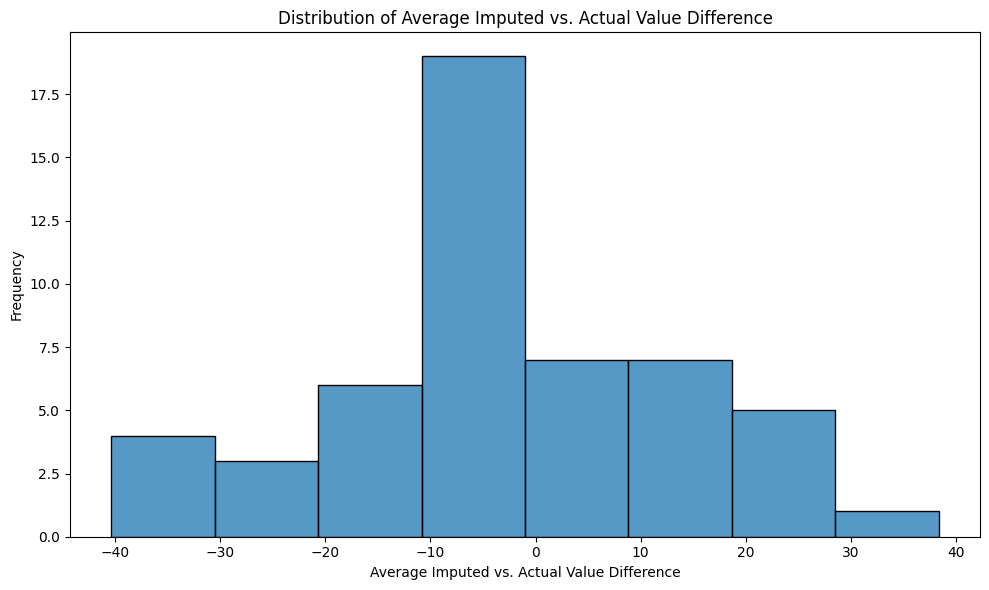

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(comparison_df["avg of seeds and actual value difference"].dropna())
plt.title('Distribution of Average Imputed vs. Actual Value Difference')
plt.xlabel('Average Imputed vs. Actual Value Difference')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()